<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/Titanic_%EA%B0%95%EC%9D%98_%EB%B2%84%EC%A0%84_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle Titanic 입문 (머신러닝 입문)

##타이타닉 EDA to Prediction

######타이타닉 챌린지는 나이, 성별 또는 승객 클래스와 같은 변수를 기반으로 주어진 승객의 생존 또는 사망을 예측하는 경쟁입니다.

######앞에서 사이킷런을 공부하기 위해 동일한 샘플을 사용해 보았습니다.

######사이킷런 기반으로 분석을 해보겠습니다.
######사이킷런(sklearn이라고도 부름)은 무료 소프트웨어로 파이썬 프로그래밍 언어를 위한 머신러닝 라이브러리입니다.
######Classification, Regression, Clustering, Decision Tree 등의 다양한 알고리즘을 적용할 수 있는 함수들을 제공하며, 현재도 수많은 알고리즘이 추가 제공되고 있습니다.
######사이킷런 자체 샘플 데이터도 있고, UC Irvine에서 제공하는 데이터도 있습니다. 우리는 캐글 대회의 기본인 타이타닉으로 작업을 하며 이해를 높이겠습니다.





# Part1: Exploratory Data Analysis(EDA)

## Task 1 - 시작하기

* 자료 다운로드하기
[자료 다운로드](https://www.kaggle.com/c/3136/download-all)

으로 가서 파일을 다운로드 한다. (Kaggle note에서 할 때는 불러 오는 것이 좀 더 단순하나 주피터 노트북에서 할 때는 다운로드 및 임포트를 해야한다.)

* 필요한 것들을 임포트 좀 해야겠죠.



In [ ]:
import math, time, random, datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sklearn
import xgboost as xgb
import seaborn as sns
# Check available styles
# print(plt.style.available)
# Try a different seaborn style if 'seaborn-whitegrid' is indeed not available
# plt.style.use('seaborn-v0_8-whitegrid') # Example of a potentially available style
plt.style.use('seaborn-v0_8-whitegrid') # Use a common and available seaborn style

%matplotlib inline

import missingno

import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls

import warnings
warnings.filterwarnings('ignore')


from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

## Task 2 - 파일보기

* 파일을 보겠습니다.

* Kaggle에서는 우측의 Data에 가셔서 input 에서 원하는 파일을 보세요

* 다운로드한 파일을 업로드하여 임포트 합니다.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving gender_submission.csv to gender_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


* 이어서 이를 데이터프레임에 임포트하여 데이터셋이 판다스 데이터프레임에 임포트 되도록 합니다.

In [ ]:
import io
test = pd.read_csv(io.BytesIO(uploaded['test.csv']))
train = pd.read_csv(io.BytesIO(uploaded['train.csv']))
gender_submission = pd.read_csv(io.BytesIO(uploaded['gender_submission.csv']))

PI = test['PassengerId']  # 따로 잘 떼어 놓습니다. (본래 트레인과 테스트를 합쳐서 함께 작업하여야 하는데 여기서는 트레인만 가지고 연습을 할 것이라 굳이 필요한 과정은 아닙니다.)

우리가 훈련시킬 트레인 파일을 한 번 보도록 하겠습니다.

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


* 우리가 나중에 최종 시험 볼 대상인 test 파일을 보겠습니다.

In [ ]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


* 마지막으로 우리가 제출할 포맷이 될 gender submission 파일을 보겠습니다.

In [ ]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


* 보시다시피 Passenger id 는 단지 누구가 누구이다 라는 것을 밝히는 identifier인 것 같고
* Survived 는 0이면 사망이고 1이면 살아 남은 사람인 것 같습니다.
* 그럼 일단 훈련시킬 train 파일에 집중하도록 하겠습니다.
* 파일의 길이를 보지요

In [ ]:
len(train)

891

* 891명에 대한 데이터 입니다.

#### Iniital (Wild) Guess

* 항목을 보면 PClass 는 객실의 레벨인 것 같습니다. 1이 제일 좋은 곳이고 3이 제일 낮은 곳인 것 같습니다.
* 이름은 별 의미가 없을 수도 있으나 중간에 Mr. Miss, Mrs 등이 아닌 master, rev, capt 등이 나오는데 이는 의미가 있습니다.
* Sex는 중요합니다. 보나마나 여성과 아이들을 우선적으로 구명 보트에 타게 했을 것이므로 남성이면 사망 확률이 훨씬 높지요
* Age도 중요합니다. 어릴 수록 구명 보트에 탔을 가능성이 크니까요
* SibSp는 배우자나 형제들과 같이 탄 즉, 가족의 숫자를 나타내므로 가족이 있는 사람의 생존 확률은 컸을 것이라 사료 됩니다.
* Parch 는 부모, 아이들이 같이 탄 경우니까, 역시 생존 확률이 좀 더 높을 것이라 생각됩니다.
* Ticket은 어떻게 의미를 두어야 할지 아직 파악이 안 됩니다. Fare나 Cabin과 연관이 있을 것입니다.
* Fare는 비쌀 수록 생존 확률이 높을 가능성이 클 것으로 생각됩니다.
* Cabin도 정해진 캐빈에서의 생존률이 더 높을 수 있습니다. NaN은 Not a number란 뜻인데 아마도 크루이었거나 정확한 방 배정이 안 된 단체로 자는 사람들이 아니었나는 생각이 들기도 합니다.
* Embarked는 어디서 탔냐는 이야기인데, 큰 요인은 아닐 것이라는 것이 최초 추측이나 현대와 달리 부자 사는 동네부터 노동자 사는 동네까지 그 당시에는 확연히 달랐을 경우 영향이 있을 것이라 생각 됩니다.

* 이제 하나씩 훓어 보며 작업을 해보겠습니다.
* 우리의 목표는 train에서 모델을 뽑아서 test에서 누가 살아 남았을 확률이 큰가를 뽑아 내는 것입니다.

#### describe 보기

In [ ]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* 위를 보시면 트레인의 숫자, 중간 값, 표준편차 등이 나와 있습니다.

#### 열 헤드 보기

* 열 이름을 보겠습니다.

In [ ]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

* 우리 여기서 인덱싱 같은 것도 가능합니다. (지금 필요한 것은 아니지만 연습 삼아, 파이썬 기초 반 때 기억을 되살리며)

In [ ]:
train.columns[3]

'Name'

#### missing data 보기

##### 빠진 데이터를 보겠습니다.

* 이는 중요합니다.
* 무엇보다 데이터가 없으면 분석을 할 수가 없겠지요?
* 그리고 결측값 채우기가 아주 중요합니다


<Axes: >

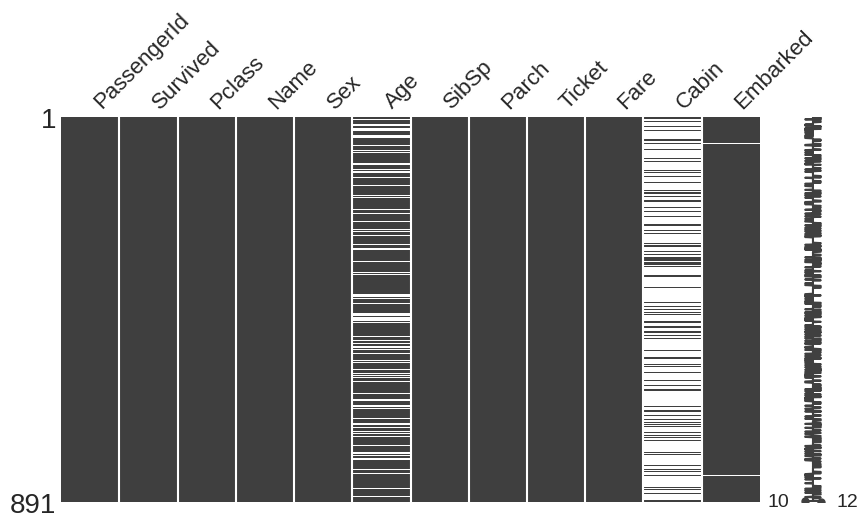

In [ ]:
import missingno
missingno.matrix(train, figsize = (10,5))

* 보시다시피 '나이'와 '캐빈' 번호에서 구멍이 많습니다.
* 빈칸의 숫자를 보겠습니다.

In [ ]:
train.isnull().sum() #비어 있는 값들을 체크해 본다.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


* sum 말고 any를 쓰면 특정 행에 비어 있는 것이 True(=빈 것 있음) False(= 빈 것 없음)를 알 수 있습니다.

In [ ]:
train.Age.isnull().any()

np.True_

* Age는 177개가 없고, Cabin 687개가 없습니다. 그리고 Embarked에도 2개의 빈 데이터가 있습니다.
* 머신러닝 툴은 빈칸을 아주 싫어 합니다.
* 나중에 이를 어떻게 할 것인지 좀 생각해 보겠습니다.

* 각 열의 데이터 타입을 보겠습니다.

In [ ]:
train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


* 나중에 오브젝트로 된 것은 컴퓨터가 분석하기 좋게 숫자로 바꾸어 주어야 할 것입니다.

#### 피쳐의 종류

#### 범주형 항목 (Categorical Features)
범주형 변수는 둘 이상의 결과 요소가 있는 변수이며 해당 기능의 각 값을 범주별로 분류 할 수 있습니다. 예를 들어 성별은 두 가지 범주 (남성과 여성)의 범주 형 변수입니다. ** 이산형 변수(discrete variable) = 범주형 변수 (categorical variable) 의 하나로 명목 변수 norminal variable **라고도합니다.

** 데이터 셋에서 명목 항목 : Sex, Embark ** 이며 우리는 Name, Ticket 등을 이로 변환해야 할 것 같습니다.

Ordinal Variable :
순위 변수는 범주 형의 하나지만 그 차이점은 값 사이의 상대 순서(=서열) 또는 정렬이 가능하다는 것입니다. 예를 들어 값이 ** Tall, Medium, Short ** 인 ** Height **와 같은 피처가있는 경우 Height는 서수 변수입니다. 여기서 변수에 상대적인 정렬을 할 수 있습니다.

** 데이터 셋에서 순위 항목 : PClass ** 이며 우리는 Cabin을 이 범주로 변환해서 사용해야 할 것 같습니다.

#### 연속형 항목 (Continuous Features):
서로 연속된 값을 가진 변수를 가진 항목이며 여기에서 우리는 연령을 대표적인 것으로 볼 수 있습니다.

** 데이터 셋에서 순위 항목 : Age ** 이며, Age, SipSp, Parch, Fare는 interval variable로 만들어 이에 적용해야 할 것 같습니다.


####항목 정보

https://www.kaggle.com/c/titanic/data
* 위의 링크에 가면 데이터 항목의 딕쇼너리를 보실 수 있습니다.

      Variable       Definition                Key

      survival	    Survival	             0 = No, 1 = Yes

      pclass	      Ticket class	         1 = 1st, 2 = 2nd, 3 = 3rd

      sex	          Sex

      Age	          Age in years

      sibsp	        # of siblings / spouses aboard the Titanic

      parch	        # of parents / children aboard the Titanic

      ticket	      Ticket number

      fare	        Passenger fare

      cabin	        Cabin number

      embarked	    Port of Embarkation	     C = Cherbourg, Q = Queenstown, S = Southampton

* 이제 데이터 탐구를 위해 본래 train은 그냥 두고 df란 것을 카피해서 써 봅니다.

In [ ]:
df = train.copy()

## Task 3 - "Surived" 분석

* 한 열씩 검토해 보겠습니다.

1. Survived -  ** Key: (0 - Not Survived, 1- Survived) **

* Survived는 수자로 값을 주지만 Categorical Variable인 셈입니다.
* 죽던지 살던지 둘 중 하나의 값을 줍니다.

* countplot을 그려 봅니다.
* 사이즈는 가로 10인치 세로 2인치
* 생존 여부 0과 1의 숫자를 세어 본 후 그림을 그리도록 명령을 하는 것입니다.

Survived
0    549
1    342
Name: count, dtype: int64


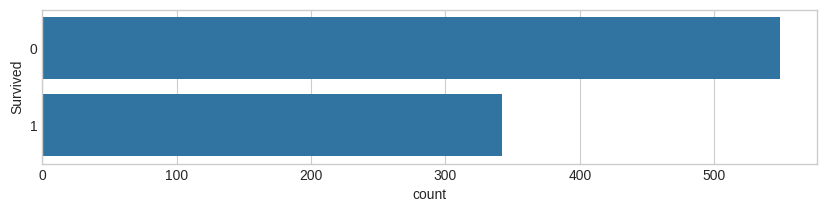

In [ ]:
fig = plt.figure(figsize=(10,2))
sns.countplot(y='Survived', data=df)
print(df.Survived.value_counts())

* 불행히도 사망자가 훨씬 많아 보입니다.
* 전체 사망자 비율을 좀 보겠습니다.

* 파이그래프랑 카운트 플롯을 서브플롯으로 그립니다.
* 행은 하나 열은 2개의 서브 플롯입니다. 사이즈는 가로 15인치 세로 6인치
* 'Survived'의 값을 카운트해서 파이플롯을 만듭니다.
* explode는 폭발하는 것이니까 1이면 튀어 나가는 것인데 0을 주면 분리만 되고 돌출은 되지 않습니다. 이어서 0, 1인 것은 첫 번째 것은 아니고 두번 째 것은 분리된다는 의미로 생각하시면 됩니다.
* autopercent는 1.1이 표현하는 부분은 소수점 한 자리까지 보여 주라는 의미입니다. 뒤에 점 이하가 4면 둘 다 소수점 4자리수 까지 보여 줍니다.
* ax[0]은 첫번째 칸입니다.
* set_title 메소드는 서브 플롯의 제목을 보여 줍니다.   

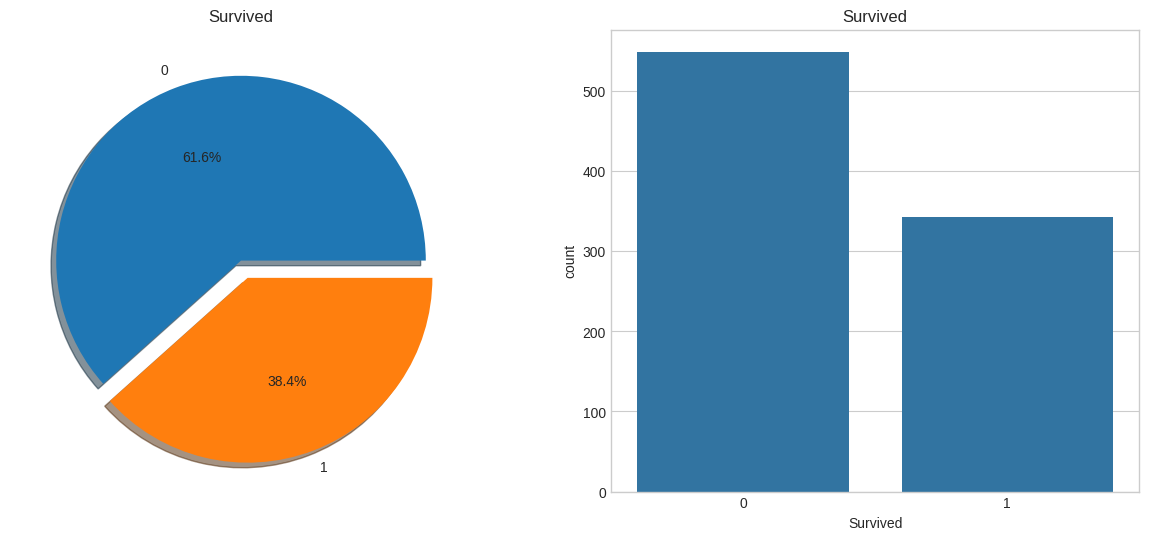

In [ ]:
f,ax=plt.subplots(1,2,figsize=(15,6))
df['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
# Explicitly specify the 'x' argument
sns.countplot(x='Survived',data=df,ax=ax[1])
ax[1].set_title('Survived')
plt.show()

## Task 4 - "Pclass" 분석

* Pclass는 값이 숫자이나 서열이 정해진 Ordinal Feature이다.

Key:1 = 1st, 2= 2nd, 3 = 3rd

* 각 클래스 당 생존자를 보겠습니다.

In [ ]:
df.groupby(['Pclass','Survived'])['Survived'].count()

Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

In [ ]:
pd.crosstab(df.Pclass,df.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


*1등급 객실의 사람들은 생존자가 더 많고, 2등급은 생존자에 비해 사망자가 조금 더 많으나, 3등급은 사망자가 3배 이상 많다는 것을 알 수 있습니다.

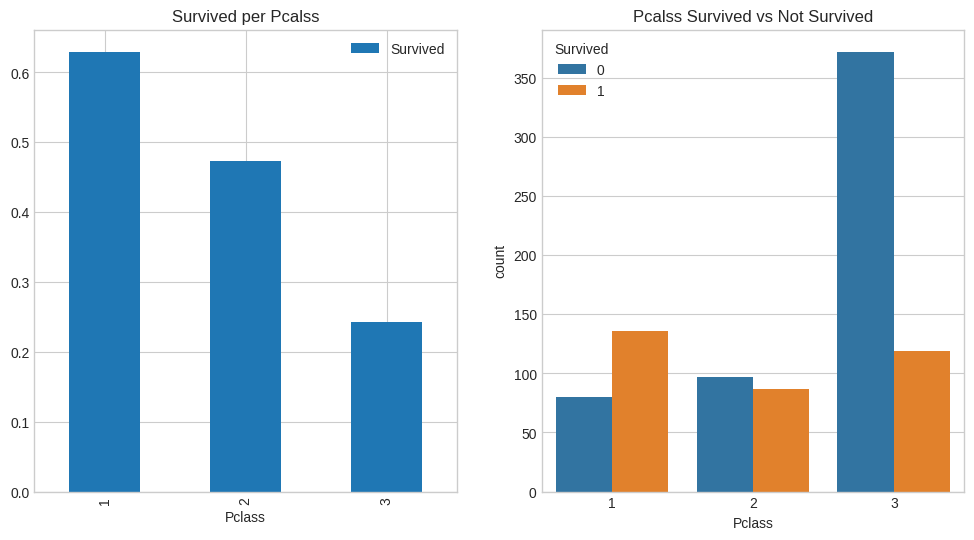

In [ ]:
f,ax=plt.subplots(1,2,figsize=(12,6))
df[['Pclass','Survived']].groupby(['Pclass']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived per Pcalss')
# Explicitly specify the 'x' argument
sns.countplot(x='Pclass',hue='Survived',data=df,ax=ax[1])
ax[1].set_title('Pcalss Survived vs Not Survived')
plt.show()

* 위의 그래프에서 생존자는 1등석이 가장 많다는 것을 알 수 있습니다.
* 각 클래스 당 생존률을 groupby로 볼까요?

In [ ]:
df.groupby('Pclass').Survived.mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


*위에 것은 함수로 만들죠

In [ ]:
def survpct(a):
  return df.groupby(a).Survived.mean()

survpct('Pclass')

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


## Task 5 - "Name" 분석

* 이름은 거의 모두 다를 가능성이 큽니다. Family Name, First Name, Middle Name and even Dr. Capt, master and so on 모두 감안하면...
* 분류를 한 번 해 봅니다.
* 리스트를 한 번 주 욱 보겠습니다.

In [ ]:
df.Name.value_counts()

,count
Name,
"Dooley, Mr. Patrick",1
"Braund, Mr. Owen Harris",1
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1
"Heikkinen, Miss. Laina",1
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
...,...
"Hewlett, Mrs. (Mary D Kingcome)",1
"Vestrom, Miss. Hulda Amanda Adolfina",1
"Andersson, Mr. Anders Johan",1


* 감이 안 옵니다. 중간에 있는 Mr. 호칭을 볼까요.
* ['Initial']이란 열을 새로 만들어서 여기에 Name에서 추출한 Regular Expression을 넣습니다.
* 아래에서 str.extract('([A-Za-z]+)\.')부분은 str에서 대문자 A~Z, 소문자 a~z 중에 \. 명령을 통해 .으로 끝나는 부분을 추출해 내는 것입니다.  
* ('^([A-Za-z]+)')으로 하면 처음에 나오는 문자 덩어리가 될 것이고 +를 빼면 첫 스펠링 한캐릭터만 추출합니다.



In [ ]:
df['Initial']=0
for i in df:
    df['Initial']=df.Name.str.extract('([A-Za-z]+)\.')

In [ ]:
df.Initial.value_counts()

,count
Initial,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
survpct('Initial')

,Survived
Initial,
Capt,0.000000
Col,0.500000
Countess,1.000000
Don,0.000000
Dr,0.428571
Jonkheer,0.000000
Lady,1.000000
Major,0.500000
Master,0.575000


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


* 생존 숫자로 봅니다.

In [ ]:
pd.crosstab(df.Initial,df.Survived).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Survived,,,,,,,,,,,,,,,,,
0,1,1,0,1,4,1,0,1,17,55,0,0,436,26,0,6,0
1,0,1,1,0,3,0,1,1,23,127,2,1,81,99,1,0,1


####하나씩 봅니다.

* Capt: 선장의 캡틴이라면 배와 같이 운명을 같이 했을 가능성이 크다. 목사님들과 함께 1그룹으로 놓겠습니다
* Col: 대령이니 중년 군인. 2그룹으로 놓겠습니다
* Countess: 여성 귀족 --> 3그룹으로 놓겠습니다
* Don: Donald의 약자 ?  -> 미스터로 4그룹으로 놓겠습니다
* Dr: 의사 선생님 --> 2그룹에 넣겠습니다
* Johnkheer: 남자 이름인듯 --> 미스터로 4그룹으로 놓겠습니다
* Lady: 여성 귀족 --> 3그룹으로 놓겠습니다
* Major: 역시 영관급이니 --> 2그룹으로 놓겠습니다
* Master: 아이들 --> 5그룹으로 놓겠습니다.
* Miss: 젊은 여성 --> 6그룹으로 넣겠습니다
* Mlle: 마드모아젤 이니 나이 많으신 여성 귀족일 가능성이 크다 -  3그룹으로 놓겠습니다
* Mme: 마담의 프랑스어 준말로 역시 나이 많으신 프랑스 여성 귀족일 가능성이 크다. -  3그룹으로 놓겠습니다
* Mr: 미스터로 4그룹으로 놓겠습니다
* Mrs: 6그룹으로 놓겠습니다.
* Ms: 요즘은 miss+mrs의 뜻이나 당시 영국에서는 한번 결혼한 여성을 ms라 불렀다. 굳이 따로 부른 것을 보면 귀족 widow가 아니었을까? - 3그룹으로 놓겠습니다
* Rev: 목사님이시니 스스로 희생했을 가능성이 크다. 1그룹으로 넣겠습니다.
* Sir: 남자 귀족 - 여성은 아니지만 귀족으로 3그룹으로 넣겠습니다.

* 참고로 항목이 너무 많아도 문제지만 너무 병합하면 확률이 확 떨어집니다.

* 이들을 번호로 바꾸겠습니다.

In [ ]:
# 1. 매핑 딕셔너리 정의
mapping = {
    'Mlle':   3, 'Mme':   3, 'Ms':     3, 'Lady':   3, 'Countess': 3,
    'Dr':     2, 'Major':  2, 'Col' :    2,
    'Jonkheer': 4,'Don':    4,'Mr':     4,
    'Rev':    1, 'Capt':   1,
    'Sir':    3,
    'Master': 5,
    'Miss':   6, 'Mrs':   6
}

# 2. 한 줄로 치환
df['Initial'] = df['Initial'].map(mapping).fillna(df['Initial'])

In [ ]:
pd.crosstab(df.Initial,df.Survived).T.style.background_gradient(cmap='summer_r')

Initial,1,2,3,4,5,6
Survived,,,,,,
0,7,6,0,438,17,81
1,0,5,7,81,23,226


In [ ]:
survpct('Initial')

,Survived
Initial,
1,0.000000
2,0.454545
3,1.000000
4,0.156069
5,0.575000
6,0.736156


* 여기서 잠시 불공평한 세상을 경험하면....Initial을 Pclass별로 나누어 보자

In [ ]:
pd.crosstab(df.Initial,df.Pclass).T.style.background_gradient(cmap='summer_r')

Initial,1,2,3,4,5,6
Pclass,,,,,,
1,1,9,6,109,3,88
2,6,2,1,91,9,75
3,0,0,0,319,28,144


* Pclass별 생존 별로 보자

In [ ]:
pd.crosstab([df.Initial,df.Survived],df.Pclass,margins=True).style.background_gradient(cmap='summer_r')

## Task 6 - "Sex" 분석



* 함수를 만들어서 보지요

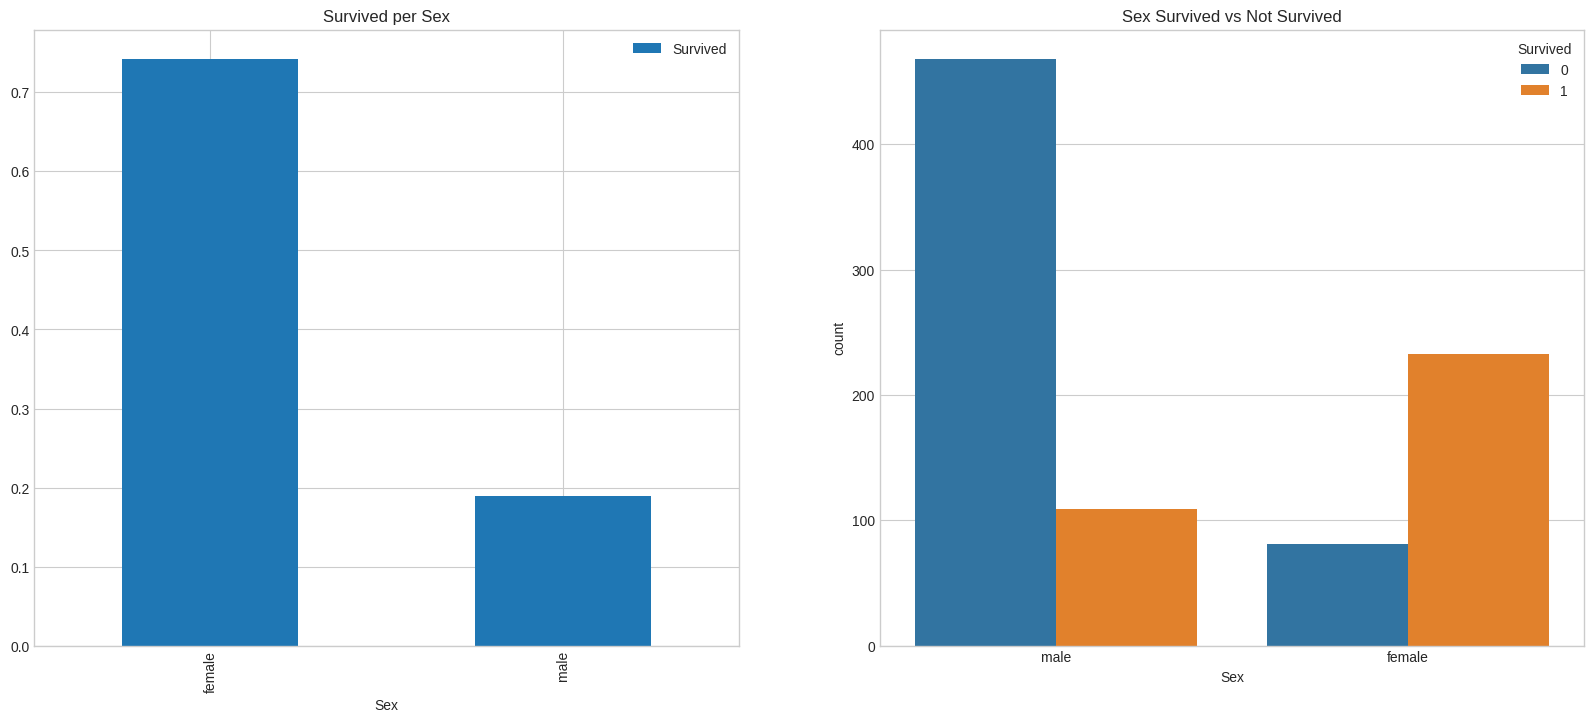

In [ ]:
def bag(a,b,c,d):
  f,ax=plt.subplots(1,2,figsize=(20,8))
  df[[a,b]].groupby([a]).mean().plot.bar(ax=ax[0])
  ax[0].set_title(c)
  # Explicitly specify the 'x' argument to resolve the TypeError
  sns.countplot(x=a,hue=b,data=df,ax=ax[1])
  ax[1].set_title(d)
  plt.show()

bag('Sex','Survived','Survived per Sex','Sex Survived vs Not Survived')

* 배에 있던 남자의 수는 여자의 수보다 훨씬 많습니다. 여전히 생존 여성 수는 남성 수의 거의 두 배입니다. ** 선박 여성의 생존율은 약 75 % 인 반면 남성의 생존율은 약 18-19 %입니다. **

* 이 것은 남성/여성을 1,2로 나누면 될 것 같은 뻔해 보이는 것이지만 좀 더 새분화하면 좋아 보입니다.
* 예를 들어 아기들은 아기이지, 남자인지 여자인지 구명보트 태울 때 안 물어 볼 것이기 때문입니다.
* 오히려 (불행하게도) 귀족 아기인지 서민의 아기인지는 행과불행을 가를 수 있습니다 ㅠㅠ
* 생존 Pclass별로 성별을 봅니다.

In [ ]:
pd.crosstab([df.Sex,df.Survived],df.Pclass,margins=True).style.background_gradient(cmap='summer_r')

In [ ]:
# 1. Initial 값이 5인 사람들만 필터링
df_filtered = df[df['Initial'] == 5]

# 2. Pclass별로 Survived 비율을 계산
survived_ratio = df_filtered.groupby('Pclass')['Survived'].mean()

# 결과 출력
print(survived_ratio)

Pclass
1    1.000000
2    1.000000
3    0.392857
Name: Survived, dtype: float64


* 성별을 남성일등석(남성 중 Pclass 1), 여성일이등석(여성 중 Pclass 1,2), 남성이삼등석(남성 중 Pclass 2,3), 여성 삼등석(여성 중 Pclass3), 일이등석 아기(이니셜5 중 Pclass 1,2), 삼등석 아기(이니셜5중 Pclass 3)로 여섯개로 나누겠습니다.

* 아래 사용되는 loc메서드 잠시 설명
* loc 메서드의 기본 구문:
```
df.loc[행_인덱스, 열_인덱스]
```
주요 특징:
행과 열의 레이블을 기반으로 접근: loc는 행 레이블과 열 레이블을 기반으로 데이터를 선택합니다. 정수 인덱스 위치와는 다르게 명시적인 레이블을 사용합니다.

* 슬라이싱(Slicing) 가능: 슬라이싱을 이용하여 범위를 지정할 수 있습니다. 슬라이싱 시 끝을 포함합니다.

* 조건부 필터링: 조건을 사용하여 행을 선택할 수 있습니다.

* 데이터 수정: loc는 데이터를 선택뿐만 아니라 수정하는 데도 사용됩니다.

In [ ]:
# Gender 컬럼을 초기화
df['Gender'] = 0

# gender 함수 정의
def gender():
    # 남성 1등석: 남성 중 Pclass == 1
    df.loc[(df['Sex'] == 'male') & (df['Pclass'] == 1), 'Gender'] = 1

    # 여성 1등석: 여성 중 Pclass == 1
    df.loc[(df['Sex'] == 'female') & (df['Pclass'] == 1), 'Gender'] = 2

    # 여성 2등석: 여성 중 Pclass == 2
    df.loc[(df['Sex'] == 'female') & (df['Pclass'] == 2), 'Gender'] = 2

    # 남성 2등석: 남성 중 Pclass == 2
    df.loc[(df['Sex'] == 'male') & (df['Pclass'] == 2), 'Gender'] = 3

    # 남성 3등석: 남성 중 Pclass == 3
    df.loc[(df['Sex'] == 'male') & (df['Pclass'] == 3), 'Gender'] = 3

    # 여성 3등석: 여성 중 Pclass == 3
    df.loc[(df['Sex'] == 'female') & (df['Pclass'] == 3), 'Gender'] = 4

    # 일등석 아기 (이니셜이 5인 아기들 중 Pclass == 1 또는 2)
    df.loc[(df['Initial'] == 5) & (df['Pclass'].isin([1, 2])), 'Gender'] = 5

    # 삼등석 아기 (이니셜이 5인 아기들 중 Pclass == 3)
    df.loc[(df['Initial'] == 5) & (df['Pclass'] == 3), 'Gender'] = 6

# 함수 실행
gender()

In [ ]:
survpct('Gender')

,Survived
Gender,
1,0.352941
2,0.947059
3,0.105263
4,0.500000
5,1.000000
6,0.392857


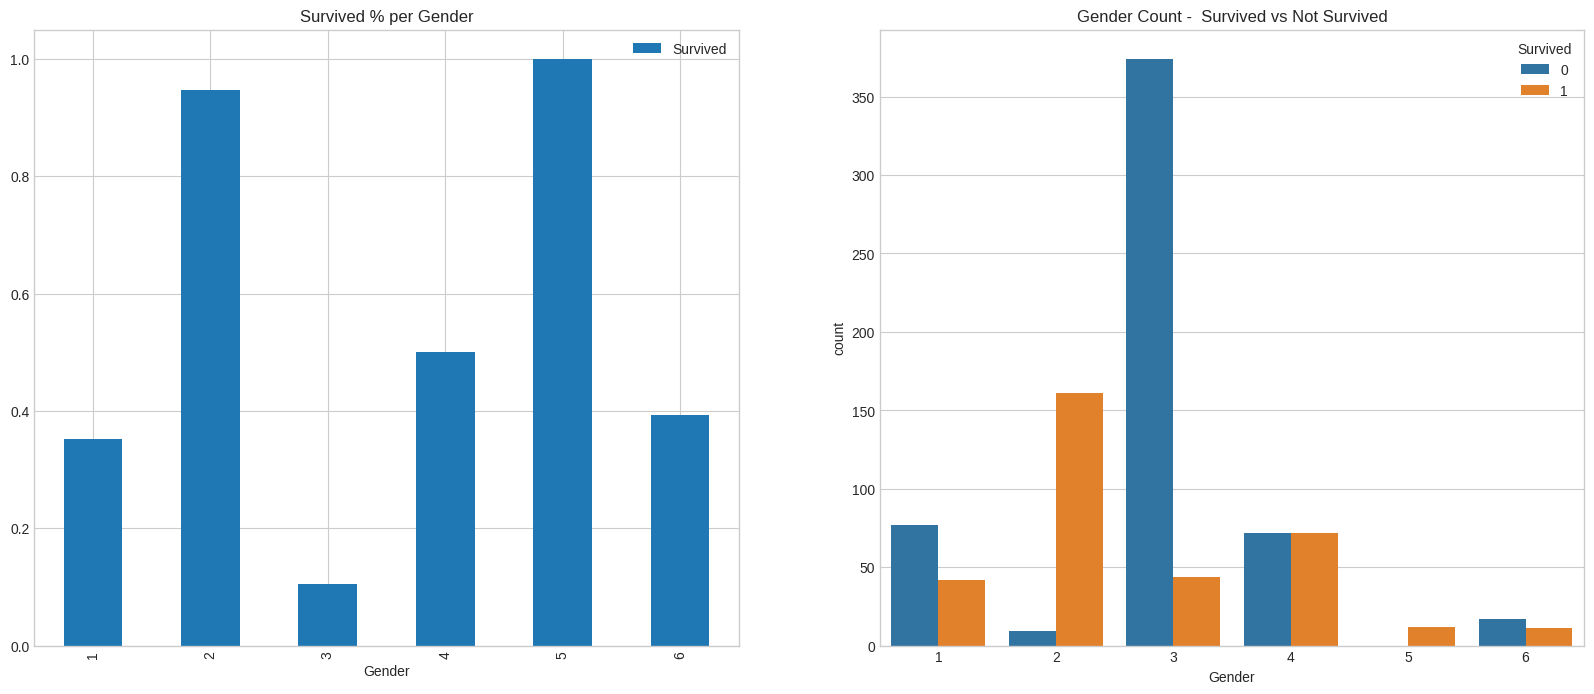

In [ ]:
bag('Gender','Survived','Survived % per Gender','Gender Count -  Survived vs Not Survived')

##Task 7 - "Age" 분석

* Age는 Continuous한 값입니다.

* Age의 최대, 최소, 중간을 보겠습니다.

In [ ]:
print('Oldest Passenger was ',df['Age'].max(),'Years')
print('Youngest Passenger was ',df['Age'].min(),'Years')
print('Average Age on the ship was ',int(df['Age'].mean()),'Years')

Oldest Passenger was  80.0 Years
Youngest Passenger was  0.42 Years
Average Age on the ship was  29 Years


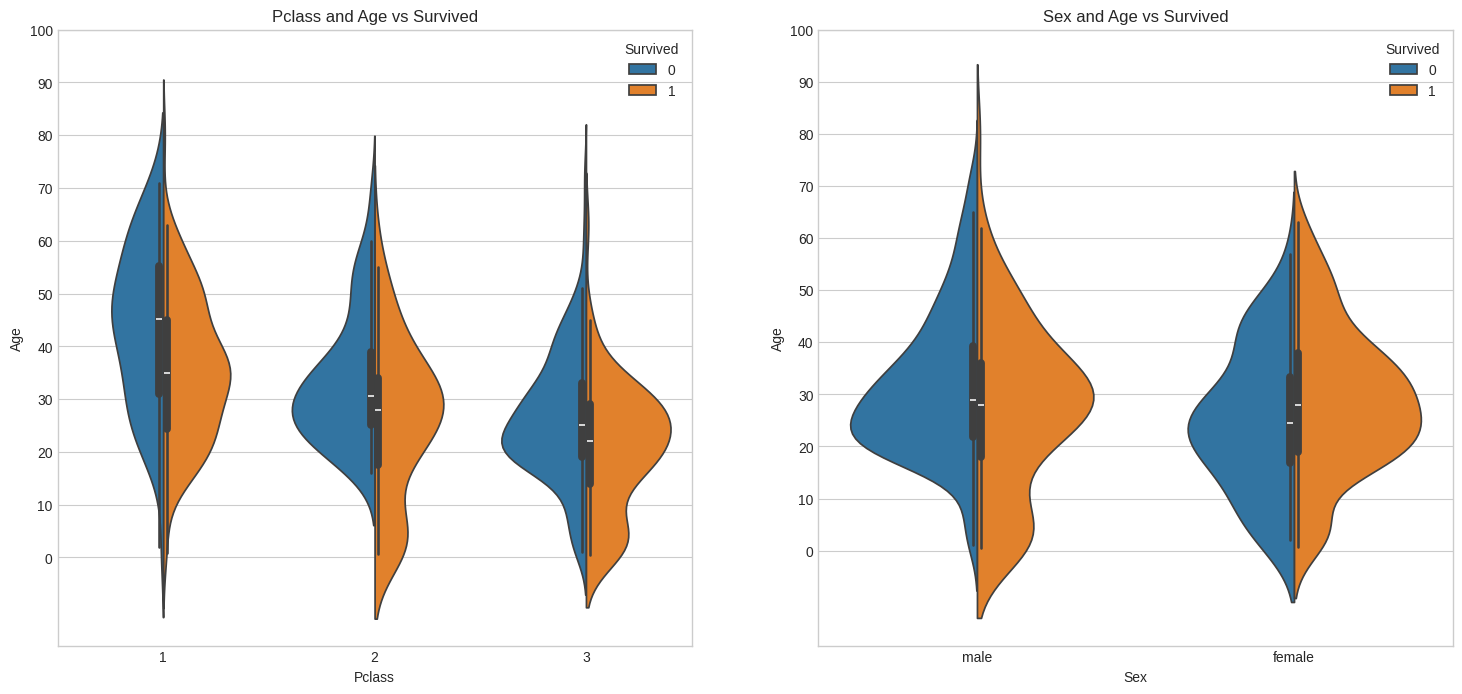

In [ ]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass", y="Age", hue="Survived", data=df,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))
sns.violinplot(x="Sex", y="Age", hue="Survived", data=df,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

* 우선 age의 빈칸 부터 해결 합니다.

* 앞에서 살펴본 것처럼 Age 항목에는 ** 177 ** null 값이 있습니다. 이러한 NaN 값을 대체하기 위해 데이터 집합의 평균 수명을 지정할 수 있습니다.

* 그러나 문제는 평균 연령이 29 세를 4세 아이에게 할당 할 수 없습니다. 승객이 어떤 연령대에 있는지 알 수있는 방법이 있을까요? 이름에서 힌트를 찾아 봅니다.

* Initial 별 평균 연령을 보고 적용 시키는 것이 좋을 것 같습니다.

In [ ]:
df.groupby('Initial')['Age'].mean() #이니셜 별 평균 연령 체크

,Age
Initial,
1,47.000000
2,46.500000
3,32.857143
4,32.401250
5,4.574167
6,27.779528


* 이니셜 별 평균 연령을 빈칸에 넣도록 합니다.

In [ ]:
# 1. 이니셜별 평균 연령 계산
mean_age_by_initial = df.groupby('Initial')['Age'].mean()

# 2. 빈 값(NaN)을 이니셜별 평균 연령으로 채우기
df['Age'] = df.apply(lambda row: mean_age_by_initial[row['Initial']] if pd.isna(row['Age']) else row['Age'], axis=1)

In [ ]:
# Age에 빈값이 있나 봅니다
df['Age'].isnull().any()

np.False_

* qcut으로 나이 그룹을 나누어 보겠습니다.

In [ ]:
# 8개의 구간으로 나누기 (에이지 데이터를 8개의 구간으로 나누며, 각 구간의 크기가 비슷하도록)
df['Age_group'] = pd.qcut(df['Age'], q=8, labels=["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7", "Q8"])

In [ ]:
df['Age_group'].value_counts()

,count
Age_group,
Q5,156
Q4,125
Q2,118
Q1,117
Q7,114
Q3,106
Q8,104
Q6,51


In [ ]:
survpct('Age_group')

,Survived
Age_group,
Q1,0.538462
Q2,0.313559
Q3,0.405660
Q4,0.488000
Q5,0.198718
Q6,0.470588
Q7,0.394737
Q8,0.365385


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Gender,Age_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,4,3,Q2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,6,2,Q7
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,6,4,Q3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,6,2,Q6
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,4,3,Q6


## Task 8 -"SibSp" 분석

* 이 항목은 탑승자가 혼자인지 또는 가족과 함께 있는지를 나타냅니다.

*Sibling = 형제, 자매, 의붓 형제, 이복 누이

Spouse = 남편, 아내

In [ ]:
pd.crosstab([df.SibSp],df.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


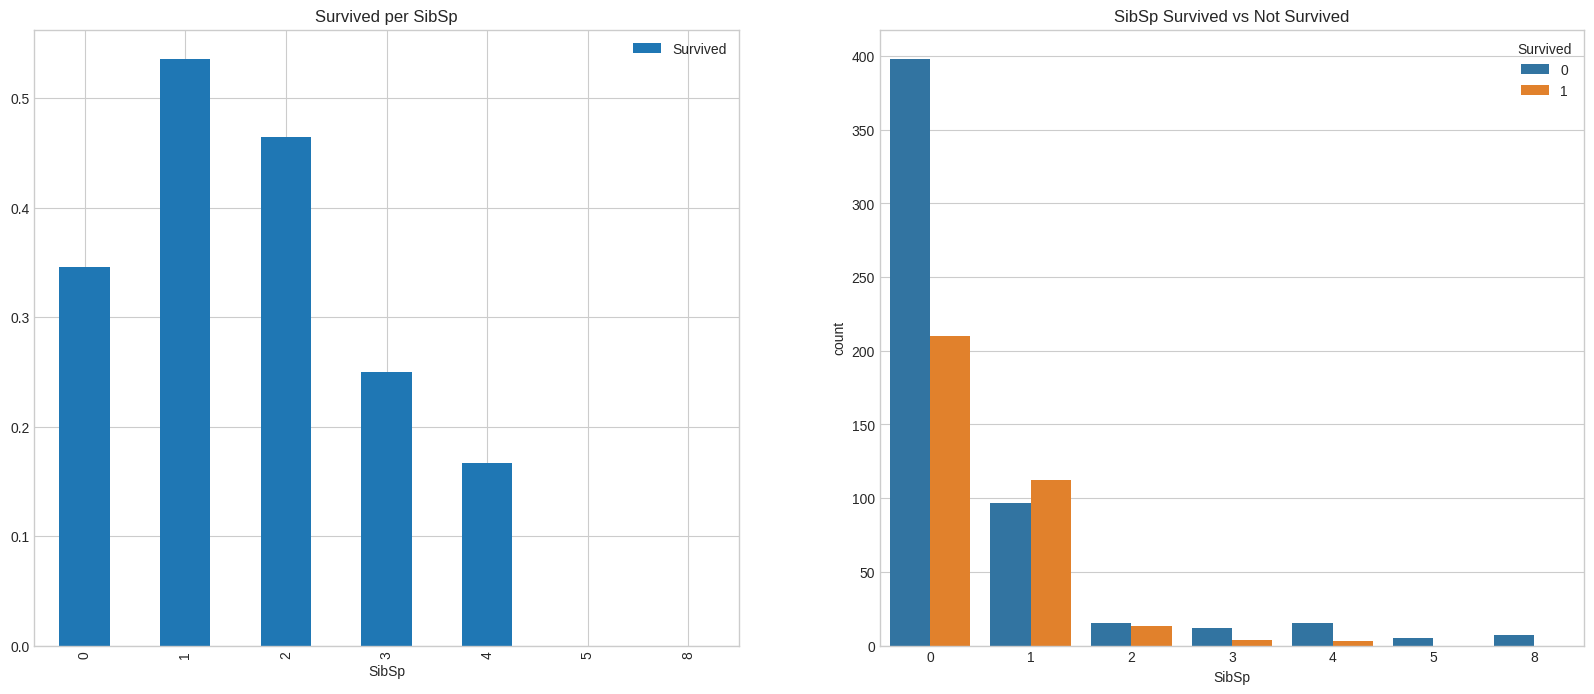

In [ ]:
bag('SibSp','Survived','Survived per SibSp','SibSp Survived vs Not Survived')

In [ ]:
survpct('SibSp')

,Survived
SibSp,
0,0.345395
1,0.535885
2,0.464286
3,0.250000
4,0.166667
5,0.000000
8,0.000000


In [ ]:
pd.crosstab(df.SibSp,df.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


In [ ]:
pd.crosstab([df.SibSp,df.Survived],df.Pclass,margins=True).style.background_gradient(cmap='summer_r')

## Task 9 - "Parch"분석

In [ ]:
pd.crosstab(df.Parch,df.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


* 크로스 탭은 다시 식구 많은 쪽은 Pclass3에 있음을 보여줍니다.

* 여기에서도 결과는 매우 비슷합니다. 부모와 함께 탑승 한 승객은 생존 가능성이 더 높습니다. 그러나 숫자가 올라 갈수록 줄어 듭니다.

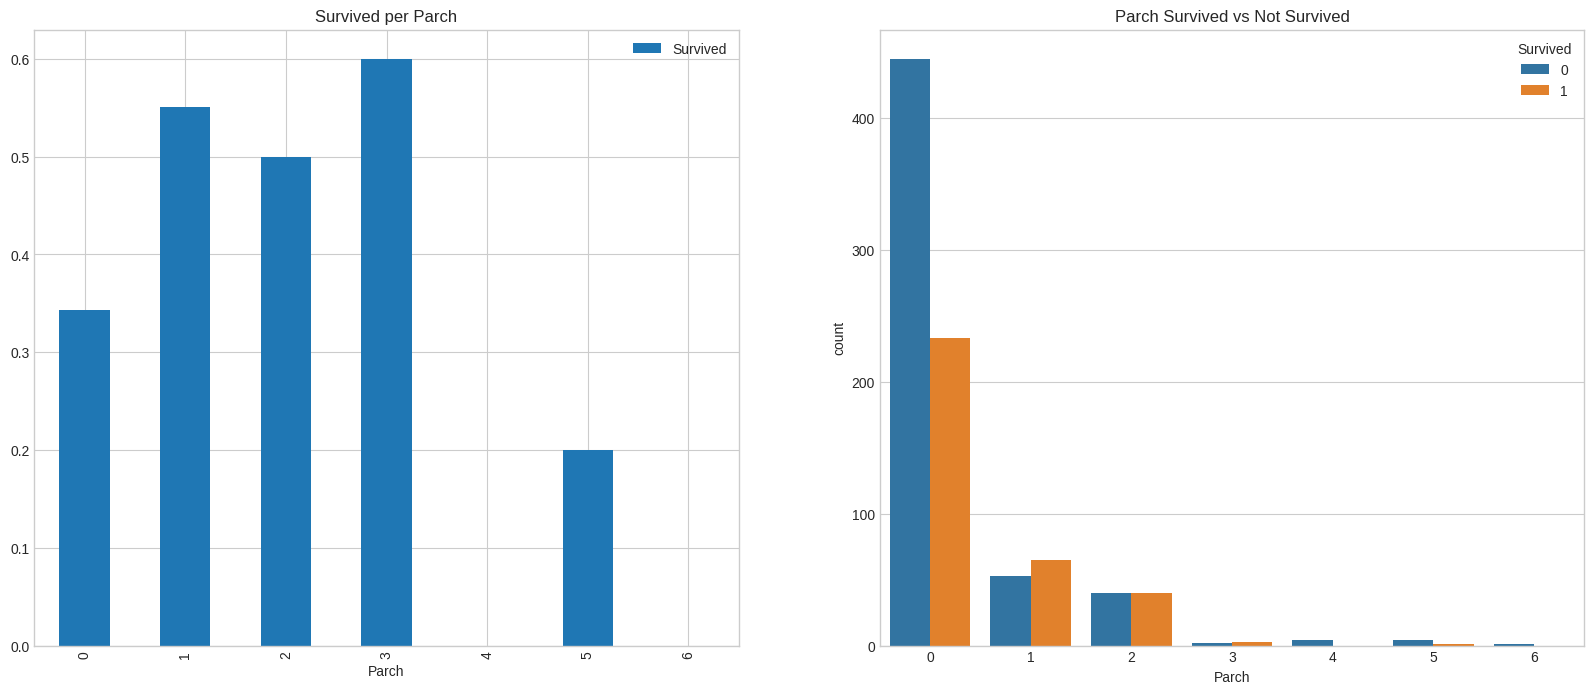

In [ ]:
bag('Parch','Survived','Survived per Parch','Parch Survived vs Not Survived')

In [ ]:
#SibSP과 Parch를 패밀리로 만들어 둘을 합쳐 봅니다
# 'SibSP'와 'Parch'를 합쳐서 'Family' 컬럼 생성
df['Family'] = df['SibSp'] + df['Parch']

# 결과 확인
print(df[['SibSp', 'Parch', 'Family']].head())

   SibSp  Parch  Family
0      1      0       1
1      1      0       1
2      0      0       0
3      1      0       1
4      0      0       0


In [ ]:
# Family 값을 기준으로 4개의 그룹으로 나누기
def categorize_family(family_size):
    if family_size == 0:
        return 1
    elif family_size in [1, 2]:
        return 2
    elif family_size in [3, 4]:
        return 3
    else:
        return 4

# 'Family' 컬럼을 기준으로 새로운 'Family_Group' 컬럼 생성
df['Family_Group'] = df['Family'].apply(categorize_family)

In [ ]:
df['Family_Group'].value_counts()

,count
Family_Group,
1,537
2,263
4,47
3,44


## 10 - "Ticket"분석

* 티켓에서 같은 번호를 가진 사람을 살펴 보겠습니다.

In [ ]:
# 'Ticket' 번호가 동일한 사람을 찾기
# 'Ticket'을 기준으로 고유 번호를 부여
df['Ticket_Group'] = pd.factorize(df['Ticket'])[0]

df['Ticket_Group'].value_counts()

,count
Ticket_Group,
13,7
72,7
148,7
49,6
58,6
...,...
665,1
6,1
5,1


## Task 11 - "Fare" 분석

In [ ]:
print('Highest Fare was:',df['Fare'].max())
print('Lowest Fare was:',df['Fare'].min())
print('Average Fare was:',df['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


흠...공짜표도 있었군요

* Fare를 그룹으로 나누어 놓겠습니다.
* qcut을 활용하면 원하는 조각으로 데이터를 나누어 줍니다.

In [ ]:
df['Fare_Range']=pd.qcut(df['Fare'],6)

In [ ]:
survpct('Fare_Range')

,Survived
Fare_Range,
"(-0.001, 7.775]",0.205128
"(7.775, 8.662]",0.190789
"(8.662, 14.454]",0.366906
"(14.454, 26.0]",0.436242
"(26.0, 52.369]",0.417808
"(52.369, 512.329]",0.697987


## Taks 12 - "Cabin" 분석

In [ ]:
df.Cabin.isnull().sum()

np.int64(687)

* 빈칸이 무척 많습니다.

## Task 13 - "Embarked" 분석

* 승선 장소 별로 숫자를 봅니다.

In [ ]:
df.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
survpct('Embarked')

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


* 관찰 :
1) S에서 탑승 최대. 대다수는 Pclass3

2) C의 승객들은 많은 비율이 살아남았습니다. 그 이유는 Pclass1 및 Pclass2 승객이 많아서 일 것입니다

3) Embark S는 대부분의 부자들이 탑승한 항구지만 생존 가능성은 낮습니다. Pclass3의 승객도 많았습니다.

4) 포트 Q는 승객의 거의 95 %가 Pclass3

* 빈칸이 두개 있는데 보겠습니다.

In [ ]:
df.loc[(train.Embarked.isnull())]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Gender,Age_group,Family,Family_Group,Ticket_Group,Fare_Range
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,6,2,Q7,0,1,60,"(52.369, 512.329]"
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,6,2,Q8,0,1,60,"(52.369, 512.329]"


* 두 사람의 티켓 번호가 같습니다.

* 가장 비슷한 번호를 찾아 보겠습니다.

In [ ]:
df.sort_values(['Ticket'], ascending = True)[35:45]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Gender,Age_group,Family,Family_Group,Ticket_Group,Fare_Range
356,357,1,1,"Bowerman, Miss. Elsie Edith",female,22.00000,0,1,113505,55.0000,E33,S,6,2,Q2,1,2,154,"(52.369, 512.329]"
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.00000,0,1,113509,61.9792,B30,C,4,1,Q8,1,2,53,"(52.369, 512.329]"
351,352,0,1,"Williams-Lambert, Mr. Fletcher Fellows",male,32.40125,0,0,113510,35.0000,C128,S,4,1,Q5,0,1,305,"(26.0, 52.369]"
252,253,0,1,"Stead, Mr. William Thomas",male,62.00000,0,0,113514,26.5500,C87,S,4,1,Q8,0,1,225,"(26.0, 52.369]"
61,62,1,1,"Icard, Miss. Amelie",female,38.00000,0,0,113572,80.0000,B28,NaN,6,2,Q7,0,1,60,"(52.369, 512.329]"
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.00000,0,0,113572,80.0000,B28,NaN,6,2,Q8,0,1,60,"(52.369, 512.329]"
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.00000,1,2,113760,120.0000,B96 B98,S,6,2,Q1,3,3,334,"(52.369, 512.329]"
390,391,1,1,"Carter, Mr. William Ernest",male,36.00000,1,2,113760,120.0000,B96 B98,S,4,1,Q7,3,3,334,"(52.369, 512.329]"
802,803,1,1,"Carter, Master. William Thornton II",male,11.00000,1,2,113760,120.0000,B96 B98,S,5,5,Q1,3,3,334,"(52.369, 512.329]"
763,764,1,1,"Carter, Mrs. William Ernest (Lucile Polk)",female,36.00000,1,2,113760,120.0000,B96 B98,S,6,2,Q7,3,3,334,"(52.369, 512.329]"


* 앞 뒤로 모두 S이고 Pclass도 모두 1인 것으로 봐서 S일 가능성이 큽니다.

In [ ]:
df.loc[(df.Embarked.isnull()),'Embarked']='S'

* 이제 빈 값이 없나 봅니다.

In [ ]:
df['Embarked'].isnull().any()

np.False_

## Task 14  - string을 수치로 바꾸기

* 이제 문자로 된 항목들 수치로 바꾸어 봅니다.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Gender,Age_group,Family,Family_Group,Ticket_Group,Fare_Range
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,4,3,Q2,1,2,0,"(-0.001, 7.775]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,6,2,Q7,1,2,1,"(52.369, 512.329]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,6,4,Q3,0,1,2,"(7.775, 8.662]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,6,2,Q6,1,2,3,"(52.369, 512.329]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,4,3,Q6,0,1,4,"(7.775, 8.662]"


In [ ]:
# 1. Embarked 수치화
df['Embarked'] = pd.factorize(df['Embarked'])[0]

# 2. AgeGroup 수치화
df['Age_group'] = pd.factorize(df['Age_group'])[0]

# 3. FareRange 수치화
df['Fare_Range'] = pd.factorize(df['Fare_Range'])[0]

In [ ]:
# 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family' 컬럼 제거
df = df.drop(columns=['Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family'])

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Initial,Gender,Age_group,Family_Group,Ticket_Group,Fare_Range
0,1,0,3,4,3,0,2,0,0
1,2,1,1,6,2,1,2,1,1
2,3,1,3,6,4,2,1,2,2
3,4,1,1,6,2,3,2,3,1
4,5,0,3,4,3,3,1,4,2


* 관계 heatmap을 봅니다.

<Axes: title={'center': 'Correlation of Features'}>

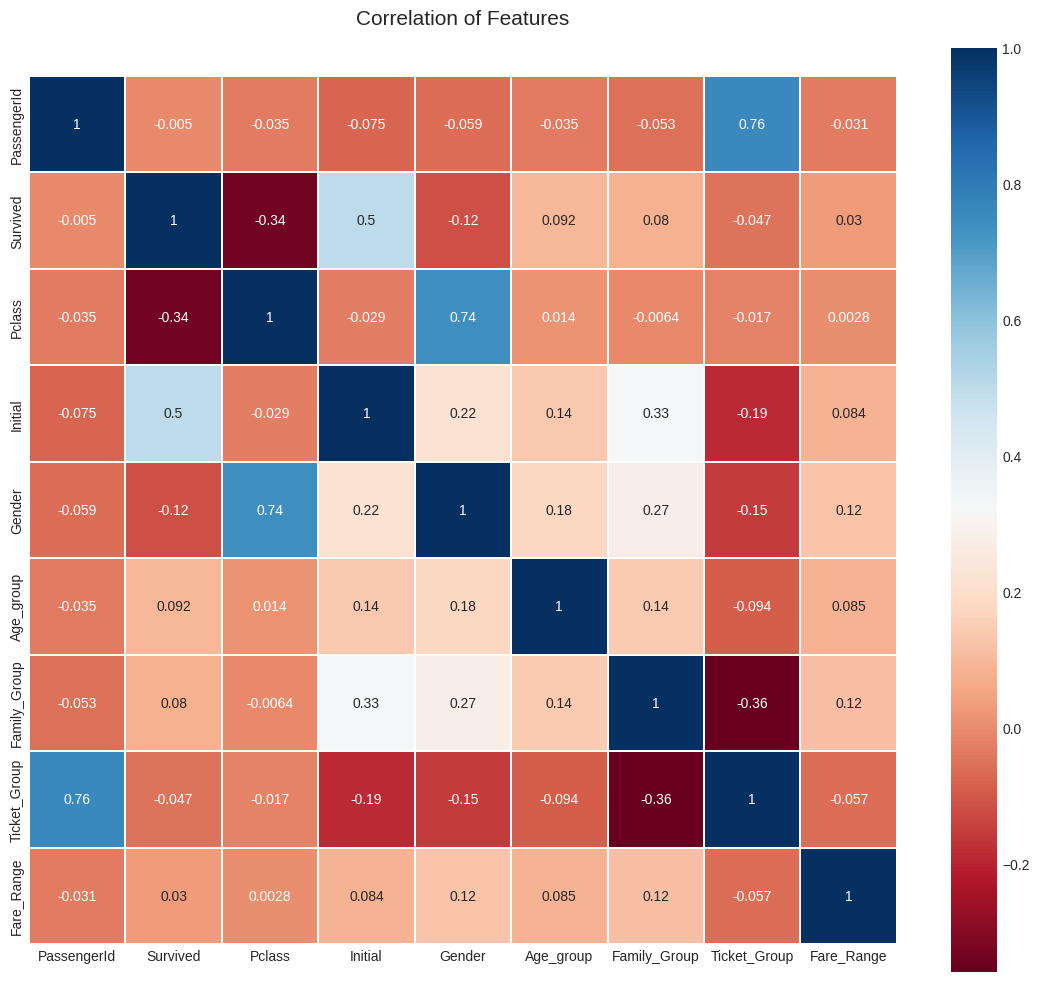

In [ ]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))

plt.title('Correlation of Features', y=1.05, size=15)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0,
            square=True, cmap=colormap, linecolor='white', annot=True)

In [ ]:
#이제 모델을 만듭니다. 위에 임포트 하기는 했지만 혹시해서 다시 임포트합니다.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


# 'PassengerId'와 'Survived'를 분리
X = df.drop(columns=['PassengerId', 'Survived'])
y = df['Survived']

# 데이터 나누기 (70% 훈련, 30% 밸리데이션)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
X_train

array([[-1.63788124,  0.3286708 ,  1.941319  , ...,  0.50188663,
         0.35336984, -0.8670853 ],
       [ 0.80326712, -0.64176479,  0.11298682, ..., -0.68248977,
         1.08522635, -0.27799681],
       [ 0.80326712,  1.2991064 ,  1.02715291, ...,  0.50188663,
        -1.48373937,  1.48926865],
       ...,
       [ 0.80326712, -0.64176479,  0.11298682, ...,  0.50188663,
         1.75733947,  1.48926865],
       [-1.63788124,  1.2991064 , -0.80117927, ...,  1.68626303,
         0.13928936, -0.8670853 ],
       [-1.63788124, -0.64176479, -1.71534536, ...,  0.50188663,
        -1.03068534, -0.8670853 ]])

In [ ]:
X_val

array([[ 0.80326712,  0.3286708 ,  2.8554851 , ...,  0.50188663,
        -1.20493689,  0.90018016],
       [-0.41730706, -0.64176479,  0.11298682, ..., -0.68248977,
         0.32847676,  1.48926865],
       [ 0.80326712, -0.64176479,  0.11298682, ..., -0.68248977,
         1.70755332, -0.27799681],
       ...,
       [-1.63788124, -0.64176479, -1.71534536, ..., -0.68248977,
         0.39817738,  0.31109167],
       [ 0.80326712, -0.64176479,  0.11298682, ..., -0.68248977,
         0.5624717 , -0.27799681],
       [-1.63788124, -0.64176479, -1.71534536, ..., -0.68248977,
         0.30358368,  0.31109167]])

In [ ]:
# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
# 모델 정의
ran = RandomForestClassifier(random_state=1)
ada = AdaBoostClassifier(random_state=1)
gbc = GradientBoostingClassifier(random_state=1)
ext = ExtraTreesClassifier(random_state=1)

# 모델 리스트
models = [ran, ada, gbc, ext]
model_names = ['Random Forest', 'AdaBoost', 'Gradient Boosting', 'Extra Trees']

# 모델 학습 및 평가
scores = {}
for ind, mod in enumerate(models):
    mod.fit(X_train, y_train)
    acc = cross_val_score(mod, X_train, y_train, scoring="accuracy", cv=5)
    scores[model_names[ind]] = acc

In [ ]:
# 결과 출력
results = pd.DataFrame(scores).T
results['mean'] = results.mean(axis=1)
result_df = results.sort_values(by='mean', ascending=False)
print(result_df)

                       0      1      2         3         4      mean
Gradient Boosting  0.792  0.872  0.784  0.814516  0.814516  0.815406
AdaBoost           0.776  0.896  0.792  0.782258  0.830645  0.815381
Random Forest      0.784  0.792  0.784  0.838710  0.814516  0.802645
Extra Trees        0.744  0.776  0.784  0.838710  0.806452  0.789832


In [ ]:
# 하드 보팅 (Hard Voting)
grid_hard = VotingClassifier(estimators=[('Random Forest', ran),
                                         ('AdaBoost', ada),
                                         ('Gradient Boosting', gbc),
                                         ('Extra Trees', ext)], voting='hard')

grid_hard.fit(X_train, y_train)
print("Hard voting accuracy on validation set: {:.2f}".format(grid_hard.score(X_val, y_val)))

# 소프트 보팅 (Soft Voting)
grid_soft = VotingClassifier(estimators=[('Random Forest', ran),
                                         ('AdaBoost', ada),
                                         ('Gradient Boosting', gbc),
                                         ('Extra Trees', ext)], voting='soft')

grid_soft.fit(X_train, y_train)
print("Soft voting accuracy on validation set: {:.2f}".format(grid_soft.score(X_val, y_val)))

Hard voting accuracy on validation set: 0.83
Soft voting accuracy on validation set: 0.81


In [ ]:
# 예측 생성
predictions_hard = grid_hard.predict(X_val)
predictions_soft = grid_soft.predict(X_val)

In [ ]:
predictions_hard

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0])

In [ ]:
predictions_soft

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0])

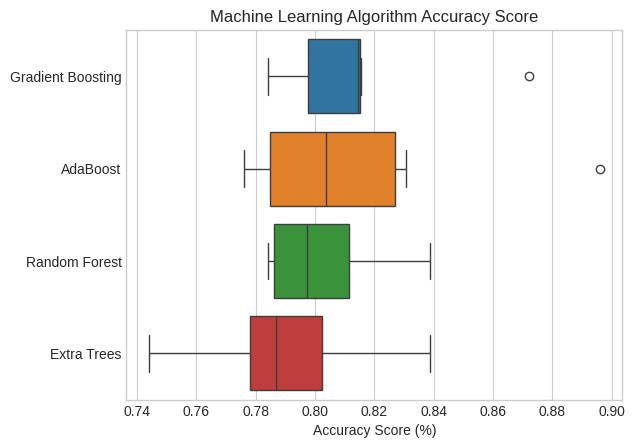

In [ ]:
# 그래프 결과
sns.boxplot(data=result_df.T, orient='h')
plt.title('Machine Learning Algorithm Accuracy Score')
plt.xlabel('Accuracy Score (%)')
plt.show()